# PINN logistic growth with heteroscedastic AR(1) noise

This notebook runs the modularized version of the user's script.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import ExperimentConfig
from data import generate_synthetic_data, compute_noise_summary
from training import fit_multi_ic_pinn, fit_sigma_ar1_repeated
from utils import set_seed, mean_and_ci
from diagnostics import plot_percentage_error_vs_state

In [3]:
# ============================================================
# Setup
# ============================================================
cfg = ExperimentConfig()
device = torch.device(cfg.device)

set_seed(cfg.seed_torch, cfg.seed_numpy)

# ============================================================
# Generate data
# ============================================================
data = generate_synthetic_data(cfg, device)

t_obs = data["t_obs"]
t_plot = data["t_plot"]
N_grid = data["N_grid"]
y_true_all = data["y_true_all"]
y_data_all = data["y_data_all"]
noise_all = data["noise_all"]
G_grid_true = data["G_grid_true"]
sigma_true_grid = data["sigma_true_grid"]

n_ics = len(cfg.N0_list)

In [4]:
# ============================================================
# Noise summary
# ============================================================
stats = compute_noise_summary(
    y_true_all=y_true_all,
    y_data_all=y_data_all,
    noise_sig_coeff=cfg.noise_sig_coeff,
    gamma=cfg.gamma,
)

print("\nNoise summary")
print("-------------")
print(f"rho_true: {cfg.rho_true:.4f}")
print(f"mean signed noise: {stats['noise_np'].mean():.6e}")
print(f"std signed noise : {stats['noise_np'].std(ddof=1):.6e}")
print(f"mean abs noise   : {stats['abs_noise_np'].mean():.6e}")
print(f"RMSE noise       : {np.sqrt(np.mean(stats['noise_np']**2)):.6e}")
print(f"mean sigma_true  : {stats['sigma_true_obs_np'].mean():.6e}")


Noise summary
-------------
rho_true: 0.5000
mean signed noise: -5.465920e-04
std signed noise : 6.854752e-02
mean abs noise   : 4.770684e-02
RMSE noise       : 6.819177e-02
mean sigma_true  : 6.299866e-02


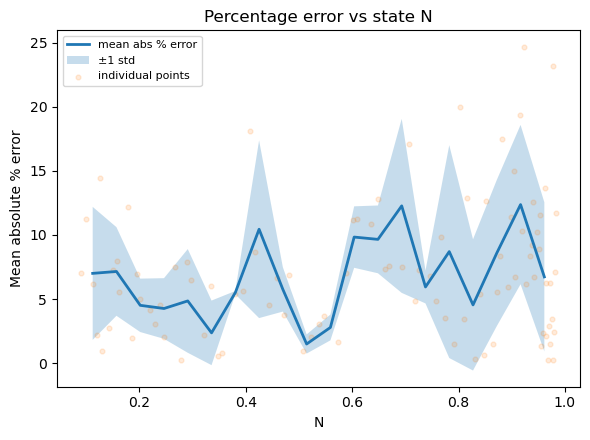

In [5]:
plot_percentage_error_vs_state(y_true_all, y_data_all)

In [6]:
# ============================================================
# Train multi-IC PINN
# ============================================================

cfg.n_epochs_pinn = 3000
cfg.lambda_g0 = 10

pinn_out = fit_multi_ic_pinn(
    cfg=cfg,
    y_data_all=y_data_all,
    t_obs=t_obs,
    t_plot=t_plot,
    N_grid=N_grid,
    n_ics=n_ics,
    device=device,
)

rhs_mean = pinn_out["rhs_mean"]
rhs_lo = pinn_out["rhs_lo"]
rhs_hi = pinn_out["rhs_hi"]

traj_mean_per_ic = pinn_out["traj_mean_per_ic"]
traj_lo_per_ic = pinn_out["traj_lo_per_ic"]
traj_hi_per_ic = pinn_out["traj_hi_per_ic"]

obs_fit_mean_per_ic = pinn_out["obs_fit_mean_per_ic"]
obs_fit_lo_per_ic = pinn_out["obs_fit_lo_per_ic"]
obs_fit_hi_per_ic = pinn_out["obs_fit_hi_per_ic"]

PINN | Split 1/4 | Epoch 1/3000 | PINN=7.046381e-01 | Optim=7.046381e-01 | Data=7.000637e-01 | Phys=4.574414e-03 | G0=0.000000e+00 | IC=1.245812e-02 | Heldout=4.663171e-01
PINN | Split 1/4 | Epoch 500/3000 | PINN=3.506744e-03 | Optim=3.506744e-03 | Data=3.374900e-03 | Phys=1.318446e-04 | G0=0.000000e+00 | IC=3.192283e-03 | Heldout=1.222619e-02
PINN | Split 1/4 | Epoch 1000/3000 | PINN=3.121130e-03 | Optim=3.121130e-03 | Data=3.020449e-03 | Phys=1.006814e-04 | G0=0.000000e+00 | IC=1.546529e-03 | Heldout=1.015952e-02
PINN | Split 1/4 | Epoch 1500/3000 | PINN=2.877045e-03 | Optim=2.877045e-03 | Data=2.717699e-03 | Phys=1.593465e-04 | G0=0.000000e+00 | IC=2.943055e-04 | Heldout=8.711708e-03
PINN | Split 1/4 | Epoch 2000/3000 | PINN=2.734707e-03 | Optim=2.734707e-03 | Data=2.591165e-03 | Phys=1.435412e-04 | G0=0.000000e+00 | IC=6.441717e-05 | Heldout=8.857757e-03
PINN | Split 1/4 | Epoch 2500/3000 | PINN=2.725359e-03 | Optim=2.725359e-03 | Data=2.505924e-03 | Phys=2.194354e-04 | G0=0.000000

In [7]:
# ============================================================
# Learn sigma(N), rho from PINN residuals
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    resid_pinn_seq_np = y_data_np - obs_fit_mean_all
    N_pinn_seq_np = np.maximum(obs_fit_mean_all, 1e-8)

N_pinn_seq = torch.tensor(N_pinn_seq_np[..., None], dtype=torch.float32, device=device)
resid_pinn_seq = torch.tensor(resid_pinn_seq_np[..., None], dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_seq.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_ar1_repeated(
    N_seq_all=N_pinn_seq,
    resid_seq_all=resid_pinn_seq,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_1,
    seed_offset_model=cfg.sigma_model_seed_base_1,
    label="PINN-sigma-AR1",
    print_every=cfg.print_every_sigma,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)
rho_pinn_mean = sigma_pinn_results["best_rhos"].mean()

PINN-sigma-AR1 | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=-5.616703e-01 | Train NLL=-5.617139e-01 | Val Total=-5.849724e-01
PINN-sigma-AR1 | Repeat 1/1 | Epoch 250/2000 | rho=0.4595 | Train Total=-2.724209e+00 | Train NLL=-2.724364e+00 | Val Total=-2.863662e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 500/2000 | rho=0.4294 | Train Total=-2.737295e+00 | Train NLL=-2.737450e+00 | Val Total=-2.867657e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 750/2000 | rho=0.4373 | Train Total=-2.757804e+00 | Train NLL=-2.757991e+00 | Val Total=-2.871592e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 1000/2000 | rho=0.4432 | Train Total=-2.766579e+00 | Train NLL=-2.766805e+00 | Val Total=-2.867859e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 1250/2000 | rho=0.4450 | Train Total=-2.767640e+00 | Train NLL=-2.767882e+00 | Val Total=-2.865852e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 1500/2000 | rho=0.4442 | Train Total=-2.768094e+00 | Train NLL=-2.768346e+00 | Val Total=-2.865969e+00
PINN-sigma-AR1 | Repeat 1/1 | Epo

In [8]:
# ============================================================
# Learn sigma(N), rho from true residuals
# ============================================================
with torch.no_grad():
    N_true_seq_np = y_true_all.squeeze(-1).cpu().numpy()
    resid_true_seq_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy()
    N_true_seq_np = np.maximum(N_true_seq_np, 1e-8)

N_true_seq = torch.tensor(N_true_seq_np[..., None], dtype=torch.float32, device=device)
resid_true_seq = torch.tensor(resid_true_seq_np[..., None], dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_seq.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_ar1_repeated(
    N_seq_all=N_true_seq,
    resid_seq_all=resid_true_seq,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_2,
    seed_offset_model=cfg.sigma_model_seed_base_2,
    label="TRUE-sigma-AR1",
    print_every=cfg.print_every_sigma,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)
rho_truefit_mean = sigma_truefit_results["best_rhos"].mean()

TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=2.659953e+00 | Train NLL=-5.892994e-01 | Val Total=2.210956e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 250/2000 | rho=0.7406 | Train Total=-2.353352e+00 | Train NLL=-2.353452e+00 | Val Total=-2.559895e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 500/2000 | rho=0.6342 | Train Total=-2.493225e+00 | Train NLL=-2.493351e+00 | Val Total=-2.666877e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 750/2000 | rho=0.5692 | Train Total=-2.675400e+00 | Train NLL=-2.675566e+00 | Val Total=-2.784031e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1000/2000 | rho=0.5162 | Train Total=-2.704905e+00 | Train NLL=-2.705095e+00 | Val Total=-2.789142e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1250/2000 | rho=0.5227 | Train Total=-2.715199e+00 | Train NLL=-2.715408e+00 | Val Total=-2.799197e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1500/2000 | rho=0.5301 | Train Total=-2.721049e+00 | Train NLL=-2.721276e+00 | Val Total=-2.805233e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch

In [9]:
# ============================================================
# Residual diagnostics
# ============================================================
with torch.no_grad():
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()
    residuals_all = y_data_np - np.array(obs_fit_mean_per_ic)
    N_fit_all = np.maximum(np.array(obs_fit_mean_per_ic), 1e-8)

    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(N_fit_all[..., None], dtype=torch.float32, device=device)
    sigma_fit_all = sigma_net_diag(N_fit_all_torch).squeeze(-1).cpu().numpy()

    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)
    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

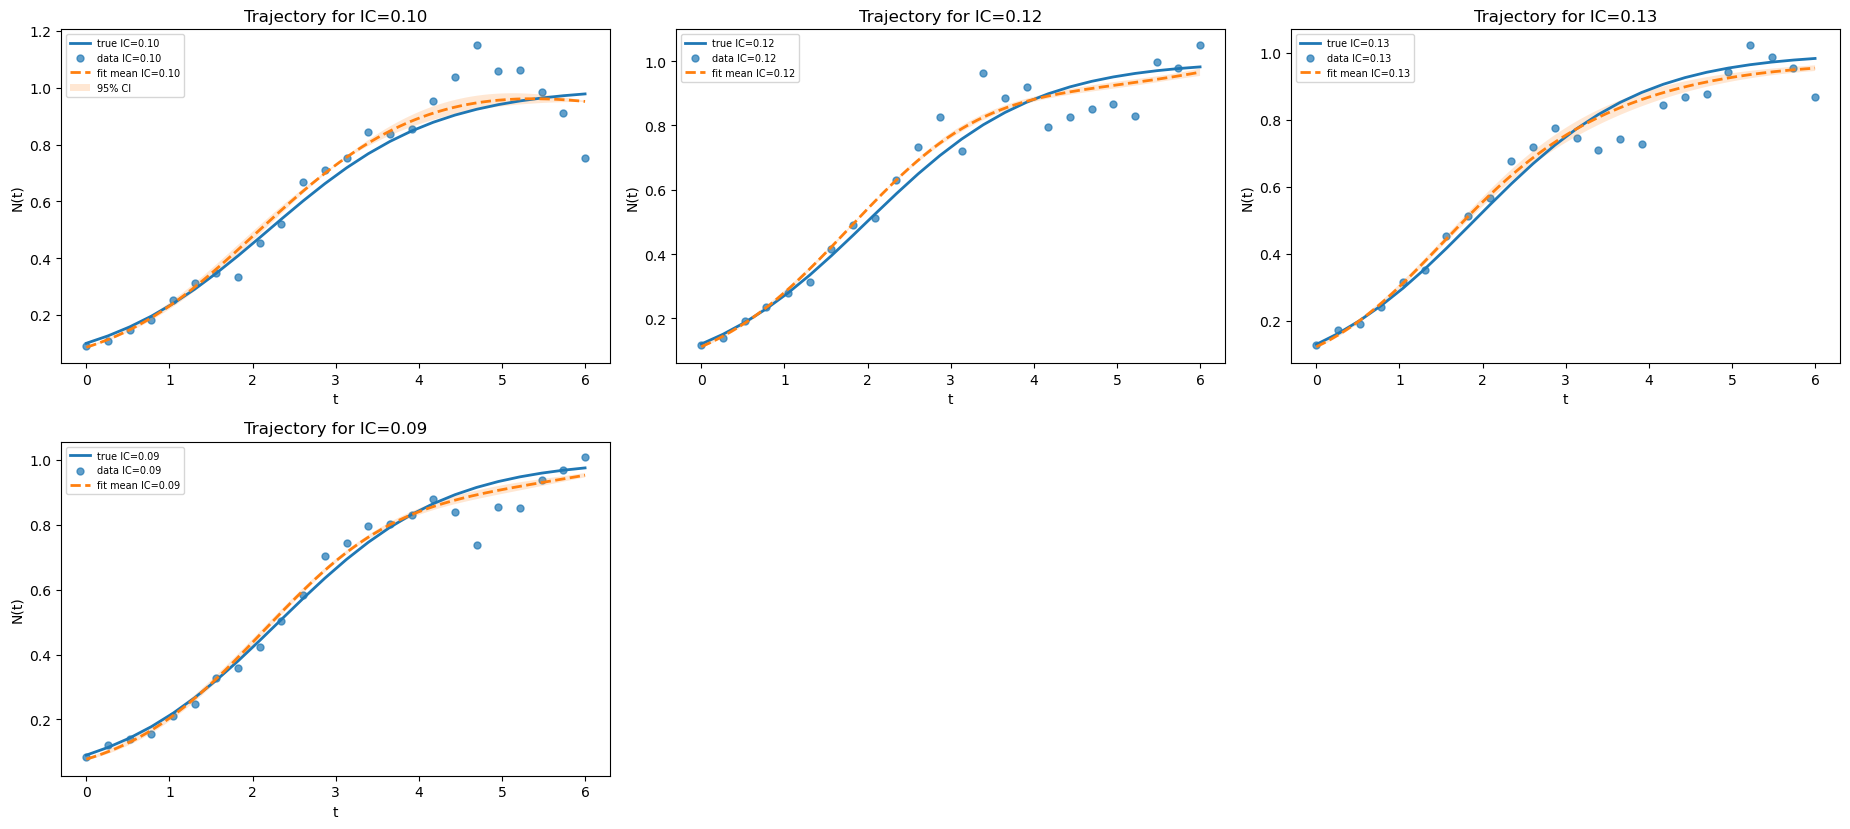

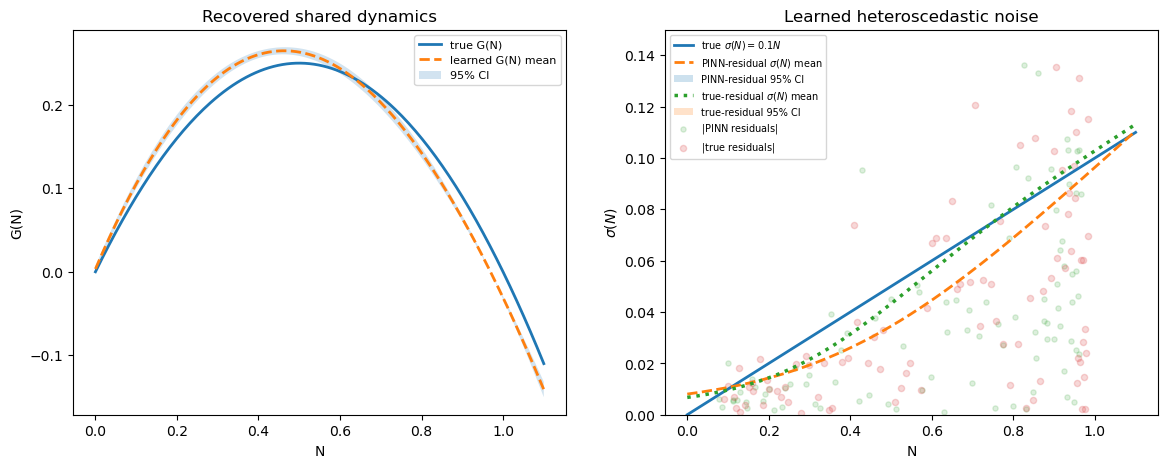

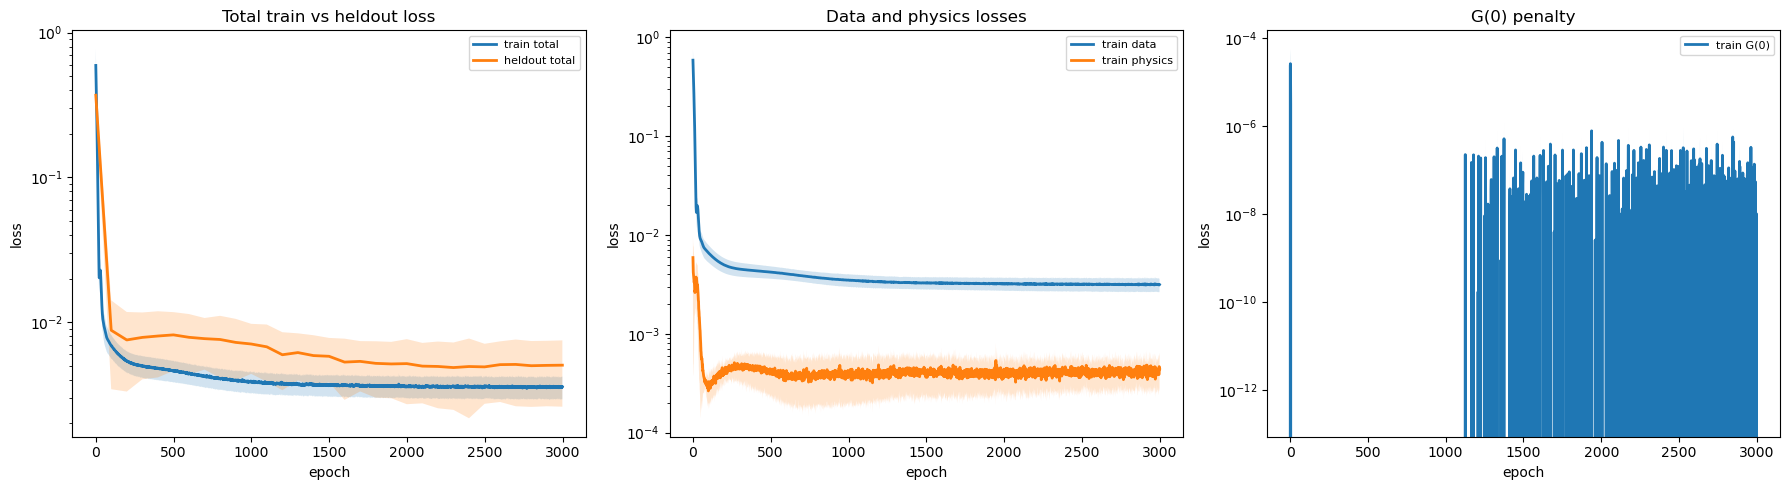

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 1: one subplot per IC
# ============================================================
ncols = 3
nrows = math.ceil(n_ics / ncols)

fig_ic, axes_ic = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.2 * nrows), squeeze=False)
axes_ic = axes_ic.flatten()

t_obs_np = t_obs.cpu().numpy()
t_plot_np = t_plot.squeeze(1).cpu().numpy()


for i in range(n_ics):
    ax = axes_ic[i]

    ax.plot(
        t_obs_np,
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={cfg.N0_list[i]:.2f}"
    )
    ax.scatter(
        t_obs_np,
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={cfg.N0_list[i]:.2f}"
    )
    ax.plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={cfg.N0_list[i]:.2f}"
    )
    ax.fill_between(
        t_plot_np,
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
        label="95% CI" if i == 0 else None
    )

    ax.set_xlabel("t")
    ax.set_ylabel("N(t)")
    ax.set_title(f"Trajectory for IC={cfg.N0_list[i]:.2f}")
    ax.legend(fontsize=7)

# Hide any unused axes
for j in range(n_ics, len(axes_ic)):
    axes_ic[j].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: summary plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Recovered shared dynamics
axes[0].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
axes[0].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean"
)
axes[0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("G(N)")
axes[0].set_title("Recovered shared dynamics")
axes[0].legend(fontsize=8)

# Learned heteroscedastic noise
axes[1].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$"
)
axes[1].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean"
)
axes[1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI"
)
axes[1].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean"
)
axes[1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI"
)
axes[1].scatter(
    N_pinn_seq.squeeze(-1).cpu().numpy().reshape(-1),
    np.abs(resid_pinn_seq.squeeze(-1).cpu().numpy().reshape(-1)),
    s=14,
    alpha=0.16,
    label=r"$|$PINN residuals$|$"
)
axes[1].scatter(
    N_true_seq.squeeze(-1).cpu().numpy().reshape(-1),
    np.abs(resid_true_seq.squeeze(-1).cpu().numpy().reshape(-1)),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$"
)
axes[1].set_xlabel("N")
axes[1].set_ylabel(r"$\sigma(N)$")
axes[1].set_title("Learned heteroscedastic noise")
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, 0.15)

# Multi-IC PINN losses
# ============================================================
# Loss plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_init = np.arange(cfg.n_epochs_pinn)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(
    pinn_out["train_pinn_total_histories"]
)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(
    pinn_out["train_data_histories"]
)
train_phys_mean, train_phys_lo, train_phys_hi = mean_and_ci(
    pinn_out["train_phys_histories"]
)
train_g0_mean, train_g0_lo, train_g0_hi = mean_and_ci(
    pinn_out["train_g0_histories"]
)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(
    pinn_out["val_total_histories"]
)

# ------------------------------------------------------------
# 1) Total training loss + total heldout loss
# ------------------------------------------------------------
axes[0].plot(epochs_init, train_pinn_total_mean, linewidth=2, label="train total")
axes[0].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)

mask = ~np.isnan(val_total_mean) & ~np.isnan(val_total_lo) & ~np.isnan(val_total_hi)

axes[0].plot(epochs_init[mask], val_total_mean[mask], linewidth=2, label="heldout total")
axes[0].fill_between(
    epochs_init[mask],
    val_total_lo[mask],
    val_total_hi[mask],
    alpha=0.2
)

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total train vs heldout loss")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# 2) Data loss + physics loss
# ------------------------------------------------------------
axes[1].plot(epochs_init, train_data_mean, linewidth=2, label="train data")
axes[1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)

axes[1].plot(epochs_init, train_phys_mean, linewidth=2, label="train physics")
axes[1].fill_between(epochs_init, train_phys_lo, train_phys_hi, alpha=0.2)

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Data and physics losses")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# 3) G(0) loss
# ------------------------------------------------------------
axes[2].plot(epochs_init, train_g0_mean, linewidth=2, label="train G(0)")
axes[2].fill_between(epochs_init, train_g0_lo, train_g0_hi, alpha=0.2)

axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("G(0) penalty")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
print("\nSummary")
print("-------")
print(f"Number of trajectories: {n_ics}")
print(f"IC values: {cfg.N0_list}")
print(f"Mean PINN best validation loss: {pinn_out['best_val_losses'].mean():.6e}")
print(f"Mean PINN best epoch: {pinn_out['best_epochs'].mean():.2f}")
print(f"PINN residual rho mean: {rho_pinn_mean:.4f}")
print(f"True residual rho mean: {rho_truefit_mean:.4f}")
print(f"Empirical standardized residual rho: {rho_empirical:.4f}")


Summary
-------
Number of trajectories: 4
IC values: (0.1, 0.12, 0.13, 0.09)
Mean PINN best validation loss: 4.604019e-03
Mean PINN best epoch: 2199.00
PINN residual rho mean: 0.4368
True residual rho mean: 0.5421
Empirical standardized residual rho: 0.4143


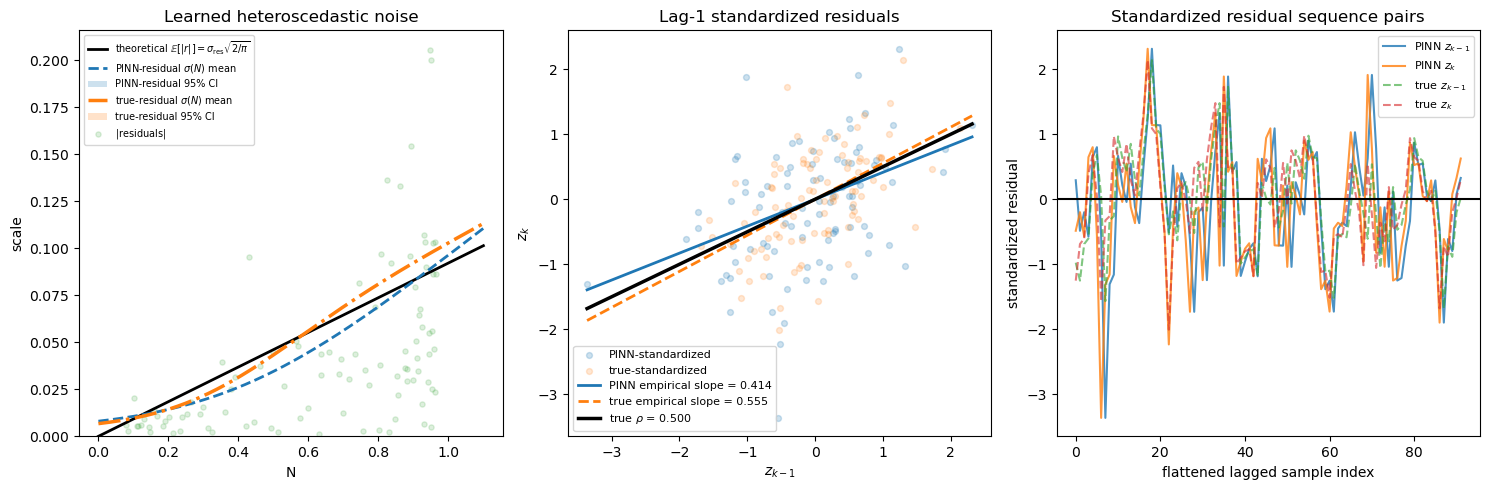

PINN empirical lag-1 slope:  0.414326
True empirical lag-1 slope:  0.554703
True rho:                    0.500000


In [13]:
# ============================================================
# Noise + AR(1) residual diagnostics on one row
# ============================================================
with torch.no_grad():
    # from synthetic data dict
    y_true_all = data["y_true_all"]             # [n_ics, T, 1]
    y_data_all = data["y_data_all"]             # [n_ics, T, 1]
    N_grid = data["N_grid"]                     # [M, 1]
    sigma_true_grid = data["sigma_true_grid"]   # innovation sigma on grid, [M, 1]

    # fitted trajectories from PINN output
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)   # [n_ics, T]

    y_true_np = y_true_all.squeeze(-1).cpu().numpy()   # [n_ics, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, T]

    # residuals against fitted mean trajectories
    residuals_all = y_data_np - obs_fit_mean_all       # [n_ics, T]
    N_fit_all = np.maximum(obs_fit_mean_all, 1e-8)     # [n_ics, T]

    # true residuals against true latent trajectories
    true_residuals_all = y_data_np - y_true_np         # [n_ics, T]
    N_true_all = np.maximum(y_true_np, 1e-8)           # [n_ics, T]

    # evaluate learned sigma(N) from PINN residual fit
    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(
        N_fit_all[..., None], dtype=torch.float32, device=device
    )                                                   # [n_ics, T, 1]

    sigma_fit_all = sigma_net_diag(N_fit_all_torch).squeeze(-1).cpu().numpy()  # [n_ics, T]

    # AR(1): true innovation sigma and true residual std / expected abs residual
    sigma_true_innovation_grid = sigma_true_grid.squeeze(1).cpu().numpy()  # [M]
    sigma_true_residstd_grid = sigma_true_innovation_grid / np.sqrt(1.0 - cfg.rho_true ** 2)
    expected_abs_resid_grid = sigma_true_residstd_grid * np.sqrt(2.0 / np.pi)

    # evaluate theoretical curves at fitted states too, for optional diagnostics
    sigma_true_innovation_fit = cfg.noise_sig_coeff * np.maximum(N_fit_all, 1e-8) ** cfg.gamma
    sigma_true_residstd_fit = sigma_true_innovation_fit / np.sqrt(1.0 - cfg.rho_true ** 2)

    # true residual std evaluated at the true latent states
    sigma_true_innovation_true = cfg.noise_sig_coeff * np.maximum(N_true_all, 1e-8) ** cfg.gamma
    sigma_true_residstd_true = sigma_true_innovation_true / np.sqrt(1.0 - cfg.rho_true ** 2)

    # standardized residuals using learned sigma fit
    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)   # [n_ics, T]

    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

    # standardized TRUE residuals using TRUE residual std
    z_true_all = true_residuals_all / np.maximum(sigma_true_residstd_true, 1e-8)  # [n_ics, T]

    z_true_prev = z_true_all[:, :-1].reshape(-1)
    z_true_next = z_true_all[:, 1:].reshape(-1)

    rho_empirical_true = np.sum(z_true_prev * z_true_next) / np.maximum(
        np.sum(z_true_prev ** 2), 1e-12
    )

    # flattened versions for plotting
    N_fit_flat = N_fit_all.reshape(-1)
    residuals_flat = residuals_all.reshape(-1)
    abs_residuals_flat = np.abs(residuals_flat)
    sigma_fit_flat = sigma_fit_all.reshape(-1)
    sigma_true_residstd_fit_flat = sigma_true_residstd_fit.reshape(-1)
    z_flat = z_all.reshape(-1)

# ============================================================
# Plot row: heteroscedastic noise + AR(1) diagnostics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

N_grid_np = N_grid.squeeze(1).cpu().numpy()

# ------------------------------------------------------------
# 1. Learned heteroscedastic noise
# ------------------------------------------------------------

axes[0].plot(
    N_grid_np,
    expected_abs_resid_grid,
    linewidth=2,
    linestyle="-",
    color="black",
    label=r"theoretical $\mathbb{E}[|r|]=\sigma_{\rm res}\sqrt{2/\pi}$"
)
axes[0].plot(
    N_grid_np,
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean"
)
axes[0].fill_between(
    N_grid_np,
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI"
)
axes[0].plot(
    N_grid_np,
    sigma_truefit_mean,
    linewidth=2.5,
    linestyle="-.",
    label=r"true-residual $\sigma(N)$ mean"
)
axes[0].fill_between(
    N_grid_np,
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI"
)
axes[0].scatter(
    N_fit_flat,
    abs_residuals_flat,
    s=14,
    alpha=0.16,
    label=r"$|$residuals$|$"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("scale")
axes[0].set_title("Learned heteroscedastic noise")
axes[0].legend(fontsize=7)

ymax0 = max(
    np.max(abs_residuals_flat) if abs_residuals_flat.size else 0.0,
    np.max(sigma_pinn_hi) if len(sigma_pinn_hi) else 0.0,
    np.max(sigma_truefit_hi) if len(sigma_truefit_hi) else 0.0,
    np.max(sigma_true_residstd_grid) if len(sigma_true_residstd_grid) else 0.0,
)
axes[0].set_ylim(0, 1.05 * ymax0)

# ------------------------------------------------------------
# 2. Lag-1 standardized residual scatter
# ------------------------------------------------------------
axes[1].scatter(z_prev, z_next, s=18, alpha=0.22, label="PINN-standardized")
axes[1].scatter(z_true_prev, z_true_next, s=18, alpha=0.18, label="true-standardized")

xmin = min(z_prev.min(), z_next.min(), z_true_prev.min(), z_true_next.min())
xmax = max(z_prev.max(), z_next.max(), z_true_prev.max(), z_true_next.max())

axes[1].plot(
    [xmin, xmax],
    [rho_empirical * xmin, rho_empirical * xmax],
    linewidth=2,
    label=fr"PINN empirical slope = {rho_empirical:.3f}"
)
axes[1].plot(
    [xmin, xmax],
    [rho_empirical_true * xmin, rho_empirical_true * xmax],
    linewidth=2,
    linestyle="--",
    label=fr"true empirical slope = {rho_empirical_true:.3f}"
)
axes[1].plot(
    [xmin, xmax],
    [cfg.rho_true * xmin, cfg.rho_true * xmax],
    color="black",
    linewidth=2.5,
    label=fr"true $\rho$ = {cfg.rho_true:.3f}"
)
axes[1].set_xlabel(r"$z_{k-1}$")
axes[1].set_ylabel(r"$z_k$")
axes[1].set_title("Lag-1 standardized residuals")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# 3. Standardized residual sequence pairs
# ------------------------------------------------------------
axes[2].plot(z_prev, label=r"PINN $z_{k-1}$", alpha=0.8)
axes[2].plot(z_next, label=r"PINN $z_k$", alpha=0.8)
axes[2].plot(z_true_prev, label=r"true $z_{k-1}$", alpha=0.6, linestyle="--")
axes[2].plot(z_true_next, label=r"true $z_k$", alpha=0.6, linestyle="--")
axes[2].axhline(0.0, color="black", linewidth=1.5)
axes[2].set_xlabel("flattened lagged sample index")
axes[2].set_ylabel("standardized residual")
axes[2].set_title("Standardized residual sequence pairs")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"PINN empirical lag-1 slope:  {rho_empirical:.6f}")
print(f"True empirical lag-1 slope:  {rho_empirical_true:.6f}")
print(f"True rho:                    {cfg.rho_true:.6f}")